# Problem Statement
**The objective of this project is to develop a predictive model that estimates crop yield based on factors such as 
rainfall, temperature, crop type, and input usage, helping optimize agricultural planning and enhance overall farm efficiency.**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [3]:
df = pd.read_csv("Crop Yield Data.csv")

In [4]:
df

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500,20.292,29.860,12.067
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000,20.292,29.860,12.067
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285,-3.143,9.582,-15.017
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.017,-3.143,9.582,-15.017


# EDA Process

In [6]:
df.shape

(19689, 13)

In [7]:
df.dtypes

Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
Avg_Temperature    float64
Max_Temperature    float64
Min_Temperature    float64
dtype: object

In [8]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64

No nulls/missing values founded.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 2.0+ MB


In [10]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000,19689.000000,19689.000000,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755186,2.410331e+07,4.884835e+04,79.954011,23.831279,33.947314,14.723357
std,6.498099,7.328287e+05,2.630568e+08,816.909592,9.494600e+07,2.132874e+05,878.306194,5.847672,5.732339,6.571713
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000,-5.115000,7.701000,-19.359000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000,23.545000,32.483000,13.535000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000,25.675000,35.826000,15.890000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.389000,26.413000,37.265000,16.983000
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000,28.652000,40.632000,24.972000


In [11]:
df["Crop"].value_counts()

Crop
Rice                     1197
Maize                     975
Moong(Green Gram)         740
Urad                      733
Groundnut                 725
Sesamum                   685
Potato                    628
Sugarcane                 605
Wheat                     545
Rapeseed &Mustard         528
Bajra                     524
Jowar                     513
Arhar/Tur                 508
Ragi                      498
Gram                      490
Small millets             485
Cotton(lint)              476
Onion                     454
Sunflower                 441
Dry chillies              419
Other Kharif pulses       382
Horse-gram                371
Peas & beans (Pulses)     369
Tobacco                   364
Other  Rabi pulses        355
Soyabean                  349
Turmeric                  337
Masoor                    324
Ginger                    323
Linseed                   308
Castor seed               300
Barley                    297
Sweet potato              273
Garli

In [12]:
df['Season'].value_counts()

Season
Kharif         8232
Rabi           5742
Whole Year     3717
Summer         1195
Autumn          414
Winter          389
Name: count, dtype: int64

**Cheaking missing value in target column**

In [13]:
df['Yield'].isnull().sum()

np.int64(0)

In [14]:
df['Yield'].describe()

count    19689.000000
mean        79.954011
std        878.306194
min          0.000000
25%          0.600000
50%          1.030000
75%          2.389000
max      21105.000000
Name: Yield, dtype: float64

In [15]:
# Feature eng

In [16]:
df.drop(['Crop_Year' ,'Production'] ,axis=1 , inplace=True)

In [17]:
df.shape

(19689, 11)

# Visiualization

<Axes: xlabel='Annual_Rainfall', ylabel='Yield'>

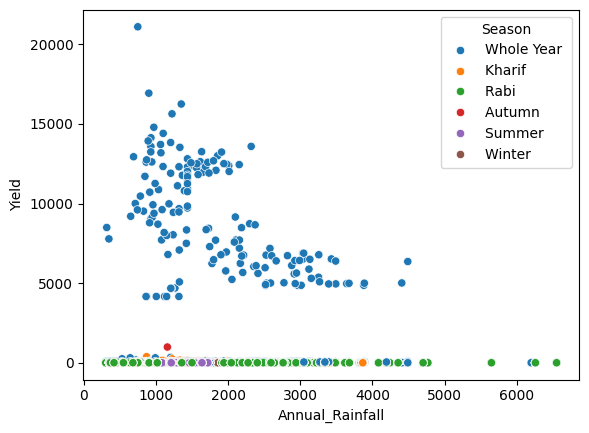

In [19]:
sns.scatterplot(data=df , x='Annual_Rainfall',y='Yield',hue="Season")

<Axes: xlabel='Avg_Temperature', ylabel='Yield'>

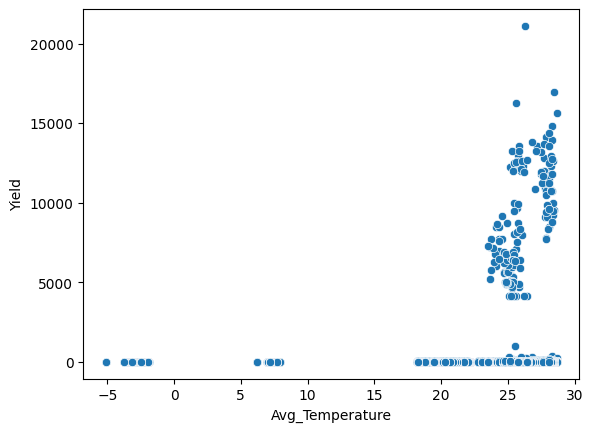

In [20]:
sns.scatterplot(data=df , x='Avg_Temperature', y='Yield')

<Axes: xlabel='Min_Temperature', ylabel='Yield'>

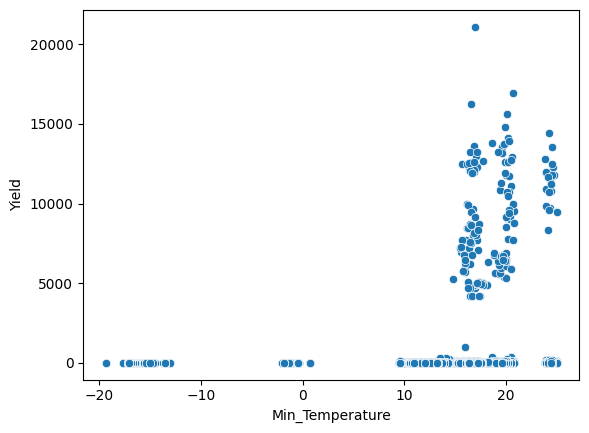

In [21]:
sns.scatterplot(data=df , x='Min_Temperature', y='Yield')

<Axes: xlabel='Max_Temperature', ylabel='Yield'>

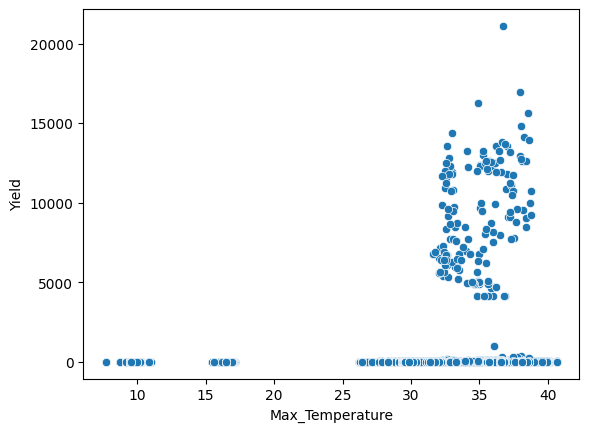

In [22]:
sns.scatterplot(data=df , x='Max_Temperature', y='Yield')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Season           19689 non-null  object 
 2   State            19689 non-null  object 
 3   Area             19689 non-null  float64
 4   Annual_Rainfall  19689 non-null  float64
 5   Fertilizer       19689 non-null  float64
 6   Pesticide        19689 non-null  float64
 7   Yield            19689 non-null  float64
 8   Avg_Temperature  19689 non-null  float64
 9   Max_Temperature  19689 non-null  float64
 10  Min_Temperature  19689 non-null  float64
dtypes: float64(8), object(3)
memory usage: 1.7+ MB


# train_test_split the data

**Define "X"as input features and "y" as Output value**

In [25]:
X = df.drop('Yield', axis=1)
y = df['Yield']

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
X_train.shape , X_test.shape

((15751, 10), (3938, 10))

# Preprocessing  the data

In [30]:
from sklearn.preprocessing import StandardScaler ,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [31]:
# Separate numerical column and categorical column

In [32]:
# Categorical Column 
cat_cols = X_train.select_dtypes(include='object').columns

In [33]:
# Numerical Column
num_cols = X_train.select_dtypes(exclude='object').columns

**Create a Column Transformer** 

In [35]:
process_data = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [36]:
X_train_process = process_data.fit_transform(X_train)
X_test_process = process_data.transform(X_test)

# Apply Model

**1. Linear Regression(Baseline)**

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
lr_model = LinearRegression()

In [40]:
lr_model.fit(X_train_process,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
# predict
y_pred_lr = lr_model.predict(X_test_process)

In [42]:
y_pred_lr

array([ 14.1001621 ,   4.99882324,  -8.04583466, ..., 152.60129993,
        11.7615863 ,  27.01775464], shape=(3938,))

**Evaluate the model**

In [43]:
from sklearn.metrics import r2_score , mean_absolute_error

In [44]:
print("r2 score:", r2_score(y_test,y_pred_lr))

r2 score: 0.8104784267595732


In [45]:
print("MAE :",mean_absolute_error(y_test,y_pred_lr))

MAE : 63.37048765731181


**2. Random Forest Regressor**

In [46]:
from sklearn.ensemble import RandomForestRegressor

In [47]:
rfr_model =RandomForestRegressor(n_estimators=100)

In [48]:
rfr_model.fit(X_train_process,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [49]:
# Predict
y_pred_rfr = rfr_model.predict(X_test_process)

In [50]:
y_pred_rfr

array([1.35877, 1.85199, 6.73936, ..., 1.35615, 0.5626 , 0.47898],
      shape=(3938,))

**Evaluate the model**

In [51]:
print("r2 Score :",r2_score(y_test,y_pred_rfr))

r2 Score : 0.969210877029393


In [52]:
print("MAE :", mean_absolute_error(y_test,y_pred_rfr))

MAE : 10.244769730827832


# Cheaking Overfitting 

In [54]:
train_pred = rfr_model.predict(X_train_process)
train_acc = r2_score(y_train,train_pred)

test_pred = rfr_model.predict(X_test_process)
test_acc = r2_score(y_test,test_pred)

In [55]:
print("Training Accuracy :",train_acc)
print("Testing Accuracy :", test_acc)

Training Accuracy : 0.9945079356262151
Testing Accuracy : 0.969210877029393


# Final Model Pipeline

In [57]:
from imblearn.pipeline import Pipeline

In [58]:
model_pipeline = Pipeline([
    ("preprocess" ,process_data),
    ("model", rfr_model)
])

In [59]:
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given 

# Save the Model

In [61]:
import joblib
joblib.dump(model_pipeline, "crop_yield_model.pkl")

['crop_yield_model.pkl']

# Deployment (Streamlit app)

In [69]:
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("crop_yield_model.pkl")

st.title("Crop Yield Prediction App")

st.write("Enter details to predict crop yield")

# User Inputs

crop = st.selectbox("Crop", ["Rice", "Wheat", "Maize",'Rice','Maize','Moong(Green Gram)'  ,      
'Urad', 'Groundnut', 'Sesamum',  'Potato' , 'Sugarcane', 'Wheat' ,'Rapeseed & Mustard' , 'Bajra', 'Jowar'  ,                   
'Arhar/Tur','Ragi','Gram','Small millets','Cotton(lint)' ,'Onion' ,'Sunflower' ,'Dry chillies','Other Kharif pulses',       
'Horse-gram' , 'Peas & beans (Pulses)',  'Tobacco', 'Other  Rabi pulses' , 'Soyabean' ,'Turmeric' ,'Masoor' , 'Ginger' ,                   
'Linseed' , 'Castor seed', 'Barley' ,'Sweet potato' , 'Garlic' , 'Banana' , 'Mesta' ,'Tapioca' ,'Coriander' ,'Niger seed' ,              
'Jute' ,'Coconut' ,'Safflower', 'Arecanut' ,'Sannhamp' ,'Other Cereals' , 'Cashewnut'  ,'Cowpea(Lobia)',  'other oilseeds',           
'Black pepper' ,'Moth' , 'Khesari' ,'Cardamom'  ,  'Guar seed ' ,'Oilseeds total' , 'Other Summer Pulses'])

season = st.selectbox("Season", ["Kharif", "Rabi", "Summer","Whole Year","Autumn","Winter"])

state = st.selectbox("State", ['Andhra Pradesh','Arunachal Pradesh' ,'Assam','Bihar','Chhattisgarh','Delhi','Goa','Gujarat','Haryana','Himachal Pradesh','Jammu and Kashmir','Jharkhand',
                               'Karnataka', 'Kerala','Maharashtra','Manipur' ,'Meghalaya','Mizoram','Nagaland','Odisha','Puducherry' ,'Punjab', 'Sikkim', 'Tamil Nadu','Telangana',
                               'Tripura' ,'Uttarakhand','Uttar Pradesh' , 'West Bengal' ])

area = st.number_input("Area",min_value=1.0)

rainfall = st.number_input("Annual Rainfall (mm)")

fert = st.number_input("Fertilizer")

pest = st.number_input("Pesticide")

avg_temp = st.number_input("Average Temperature")

max_temp = st.number_input("Max Temperature")

min_temp = st.number_input("Min Temperature")



# Prediction
if st.button("Predict"):
    input_data = pd.DataFrame({
        'Crop': [crop],
        'Season': [season],
        'State': [state],
        'Area': [area],
        'Annual_Rainfall': [rainfall],
        'Fertilizer': [fert],
        'Pesticide': [pest],
        'Avg_Temperature': [avg_temp],
        'Min_Temperature': [min_temp],
        'Max_Temperature': [max_temp],
         
    })

    prediction = model.predict(input_data)
    st.success(f"Predicted Yield : {prediction[0]:.2f}")
    production = input_data['Area'] * prediction
    st.markdown(f"**Production** : {production[0]:.2f} ")

2026-04-12 21:49:31.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 21:49:31.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 21:49:31.830 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 21:49:31.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 21:49:31.862 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 21:49:31.866 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 21:49:31.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 21:49:31.901 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar